# EPA AQS Ozone Timeseries: Evanston Water Plant

Hourly and daily ozone data retrieved from the EPA Air Quality System (AQS) 
for the Evanston Water Plant monitoring station (17-031-7002) in Evanston, IL.

## What this notebook does
- Fetches hourly ozone sample data and daily summaries using `pyaqsapi`
- Displays station metadata (location, elevation, measurement method)
- Plots an hourly timeseries with EPA AQI color bands
- Generates a calendar heatmap showing diurnal and seasonal ozone patterns
- Shows the monthly distribution of daily peak ozone via box plots
- Plots the cumulative distribution of hourly ozone concentrations
- Identifies the top peak ozone days by 1-hour and 8-hour averages

## Key inputs (defined in cell 3)
| Variable | Value | Source |
|---|---|---|
| Parameter | `o3.code` = `"44201"` | `aqs_codes.py` |
| State | `FIPS.IL.fips` = `"17"` | `fips_codes.py` |
| County | `FIPS.IL.Cook` = `"031"` | `fips_codes.py` |
| Site | `Evanston_WP` = `"7002"` | EPA AQS Station Map |
| Year | `year = 2020` | Set in Configuration cell |

## Dependencies
- `pyaqsapi` — EPA AQS API client (requires free registration)
- `aqs_codes.py` — human-readable AQS parameter objects
- `fips_codes.py` — FIPS geographic identifiers
- `aqi_colors.py` — EPA AQI colors and breakpoints
- `plot_time_heatmap.py` — calendar heatmap function


## License
Copyright (C) 2025 Greg Anderson

This notebook is free software: 
you can redistribute them and/or modify them under the terms of the 
[GNU General Public License v3](LICENSE) as published by the Free Software Foundation.


In [ ]:
import datetime as dt
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyaqsapi as aqs

import aqs_codes
importlib.reload(aqs_codes)
from aqs_codes import o3

import plot_time_heatmap
importlib.reload(plot_time_heatmap)
from plot_time_heatmap import plot_time_heatmap
from aqs_utils import wrangle_aqs_timeseries

from aqi_colors import AQI_COLORS, aqi_boxes
from fips_codes import FIPS

## Set up EPA Air Quality Systerm (AQS) API credentials

In [2]:
# Replace the lines below with your information and uncomment them, OR run the cell below.
# AQS_USER = "your_email@example.com"   # register at https://aqs.epa.gov/aqsweb/documents/data_api.html
# AQS_KEY  = "your_key"
# aqs.aqs_credentials(username=AQS_USER, key=AQS_KEY)

In [ ]:
from pathlib import Path
from dotenv import load_dotenv
import os

load_dotenv()

AQS_USER = os.getenv("AQS_USER")
AQS_KEY = os.getenv("AQS_KEY")

if not AQS_USER or not AQS_KEY:
    raise RuntimeError(
        "Missing EPA AQS credentials. Create a .env file in this directory with:\n"
        "AQS_USER=your_email@example.com\n"
        "AQS_KEY=your_aqs_key\n\n"
        "Register for a free key at: "
        "https://aqs.epa.gov/aqsweb/documents/data_api.html"
    )

aqs.aqs_credentials(username=AQS_USER, key=AQS_KEY)

## Finding Monitoring Stations

The easiest way to find AQS station IDs is through EPA's interactive station map:

[EPA AQS Station Map](https://epa.maps.arcgis.com/apps/webappviewer/index.html?id=5f239fd3e72f424f98ef3d5def547eb5)

Use the **Layers** panel (the stacked layers icon on the right side) to select 
the pollutant or data type you are interested in.
Search for a location, click on a monitoring station, and note the **Site ID** 
which has the format `SS-CCC-NNNN` (state FIPS - county FIPS - site number).
For example, Evanston Water Plant is `17-031-7002`, giving:
- `stateFIPS = FIPS.IL.fips` → `"17"`
- `countycode = FIPS.IL.Cook` → `"031"`  
- `sitenum = "7002"`

In [4]:
# This notebook uses the Evaston Water Plant station, but you can easily modify 
# it to use any of the ten active o3 stations in Cook County, listed (N to S):

Northbrook_WP = "4201"
Evanston_WP = "7002"      # Evanston Water Plant
Regional_Office_Bldg = "4007"
Taft_HS = "1003"
IEPA_Trailer = "3103"
Cook_Co_TrailerN = "4002"
South_Water = "0032"
Com_ED_MAINT = "0076"
Village_Garage = "0001"
Cook_Co_TrailerS = "1601" 


In [ ]:
# ── Site Configuration ─────────────────────────────────────────────────────
# Change these three values to use a different monitoring station.

STATE_FIPS  = FIPS.IL.fips   # "17"
COUNTY_FIPS = FIPS.IL.Cook   # "031"
SITE_NUM    = Evanston_WP    # "7002"
SITE_NAME   = "Evanston Water Plant"   # used in plot titles

YEAR        = 2020
START_DT    = dt.datetime(YEAR, 1, 1)
END_DT      = dt.datetime(YEAR, 12, 31)

STATION_ID  = f"{STATE_FIPS}-{COUNTY_FIPS}-{SITE_NUM}"

### After running this notebook, try this

1. Change `year` to a more recent year and rerun the notebook.
2. Change `site_number` to `Northbrook_WP`.
3. Compare the top 5 ozone days at Evanston and Northbrook.
4. What time of day do the largest 8-hour ozone averages usually occur?

## Sample Data

`aqs.bysite.sampledata()` returns a DataFrame of individual air quality measurements from a single monitoring site. 
Each row represents one sample - for ozone with a 1-hour duration, one row per hour. 
Key columns include 
`sample_measurement` (the measured value), 
`units_of_measure`, 
`sample_duration`, 
`date_local`, and 
`time_local`. 
The data has already passed basic quality assurance by the state or local monitoring 
agency before submission to AQS. For a long time interval, this download can take a while.

In [ ]:
o3_hourly = aqs.bysite.sampledata(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS=STATE_FIPS,
                        countycode=COUNTY_FIPS,
                        sitenum=SITE_NUM,
                        )

In [7]:
# Verify the time step, units, and column headers

print(f"Sample duration: {o3_hourly['sample_duration'].iloc[0]}")
print(f"Units:           {o3_hourly['units_of_measure'].iloc[0]}")
pd.set_option('display.max_columns', None) 
o3_hourly.head()

Sample duration: 1 HOUR
Units:           Parts per million


,state_code,county_code,site_number,parameter_code,poc,latitude,longitude,datum,parameter,date_local,time_local,date_gmt,time_gmt,sample_measurement,units_of_measure,units_of_measure_code,sample_duration,sample_duration_code,sample_frequency,detection_limit,uncertainty,qualifier,method_type,method,method_code,state,county,date_of_last_change,cbsa_code
0,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,2020-03-01,00:00,2020-03-01,06:00,0.017,Parts per million,007,1 HOUR,1,HOURLY,0.005,None,None,FEM,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,087,Illinois,Cook,2020-06-03,16980
1,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,2020-03-01,01:00,2020-03-01,07:00,0.019,Parts per million,007,1 HOUR,1,HOURLY,0.005,None,None,FEM,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,087,Illinois,Cook,2020-06-03,16980
2,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,2020-03-01,02:00,2020-03-01,08:00,0.021,Parts per million,007,1 HOUR,1,HOURLY,0.005,None,None,FEM,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,087,Illinois,Cook,2020-06-03,16980
3,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,2020-03-01,03:00,2020-03-01,09:00,0.019,Parts per million,007,1 HOUR,1,HOURLY,0.005,None,None,FEM,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,087,Illinois,Cook,2020-06-03,16980
4,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,2020-03-01,04:00,2020-03-01,10:00,0.022,Parts per million,007,1 HOUR,1,HOURLY,0.005,None,None,FEM,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,087,Illinois,Cook,2020-06-03,16980


In [ ]:
# Site information — location, elevation, measurement methods

site_info = aqs.bysite.monitors(
    parameter=o3.code,
    bdate=START_DT,
    edate=END_DT,
    stateFIPS=STATE_FIPS,
    countycode=COUNTY_FIPS,
    sitenum=SITE_NUM
)

site_info[["local_site_name", "address", "latitude", "longitude",
           "elevation", "probe_height", "last_method_description",
           "measurement_scale", "monitoring_objective"]].drop_duplicates()

,local_site_name,address,latitude,longitude,elevation,probe_height,last_method_description,measurement_scale,monitoring_objective
0,WATER PLANT,531 E. LINCOLN,42.062053,-87.675254,183.0,10.0,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,NEIGHBORHOOD,POPULATION EXPOSURE


### Data Wrangling

Create datetime classes for plotting timeseries data.

In [ ]:
o3_max = o3_hourly['sample_measurement'].max()
o3_hourly = wrangle_aqs_timeseries(o3_hourly)

### Data Coverage

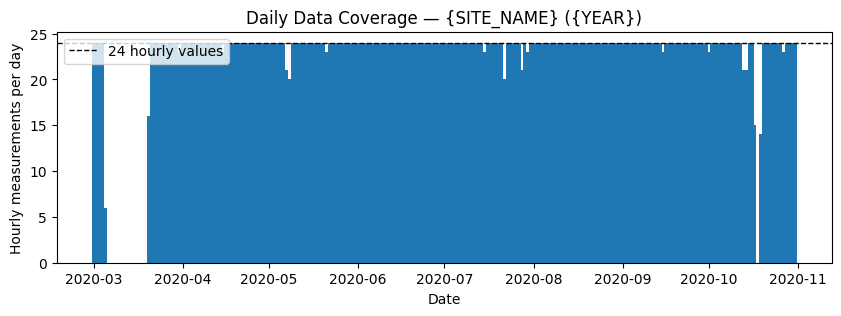

In [ ]:
# Count the number of hourly measurements available each day
daily_counts = (
    o3_hourly
    .set_index("datetime_local")
    .resample("D")["sample_measurement"]
    .count()
)

plt.figure(figsize=(10, 3))
plt.bar(daily_counts.index, daily_counts.values, width=1.0)
plt.axhline(24, color="black", linestyle="--", linewidth=1, label="24 hourly values")
plt.ylabel("Hourly measurements per day")
plt.xlabel("Date")
plt.title(f"Daily Data Coverage — {SITE_NAME} ({YEAR})")
plt.legend()
plt.show()

Each bar represents one day. A full bar indicates complete hourly coverage (24 
measurements); shorter bars indicate missing data. Gaps in coverage can result 
from instrument downtime, quality control exclusions, or data not yet submitted 
to AQS. Days with fewer than 18 valid hours are typically excluded from the 
official AQI calculation.

### Timeseries

Ozone concentration over time on an AQI background.

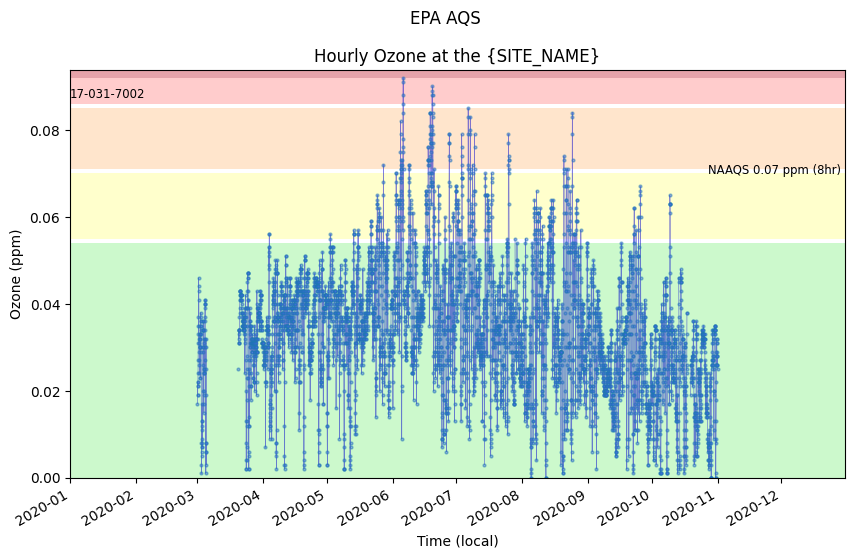

In [ ]:
fig = plt.figure(figsize=(10,6),num=f"{SITE_NAME} Ozone")
fig.suptitle('EPA AQS')
fg1a = fig.add_subplot(1, #nrows
                1, #ncols
                1) # index position
fg1a.axis([START_DT,END_DT,0,1.02*o3_max])
fg1a.set_title(f'Hourly Ozone at the {SITE_NAME}')

for box in aqi_boxes("o3_8hr", START_DT, END_DT, o3_max):
    fg1a.add_patch(box)

fg1a.plot(o3_hourly['datetime_local'],
        o3_hourly['sample_measurement'],#.rolling(8,center=True).mean(),
           label='EPA: {SITE_NAME}Ozone (ppm)',
           linestyle='solid',
           linewidth=0.5,
           color='mediumblue',
           alpha=0.5)

fg1a.plot(o3_hourly['datetime_local'],
        o3_hourly['sample_measurement'],
           label='EPA: {SITE_NAME} Ozone (ppm)',
           linestyle='none',
           linewidth=1,
           marker='o',
           markersize=2,
           mfc='royalblue',
           alpha=0.5)

fg1a.set_ylabel('Ozone (ppm)')
fg1a.set_xlabel('Time (local)')
fg1a.text(START_DT,0.95*o3_max,STATION_ID,size='smaller',horizontalalignment='left')
fg1a.text(END_DT,0.07,'NAAQS 0.07 ppm (8hr) ',size='smaller',horizontalalignment='right')
fig.autofmt_xdate()
plt.show()

### Calendar Heatmap

A colour-coded grid of calendar days that reveals daily and seasonal patterns in ozone concentration.

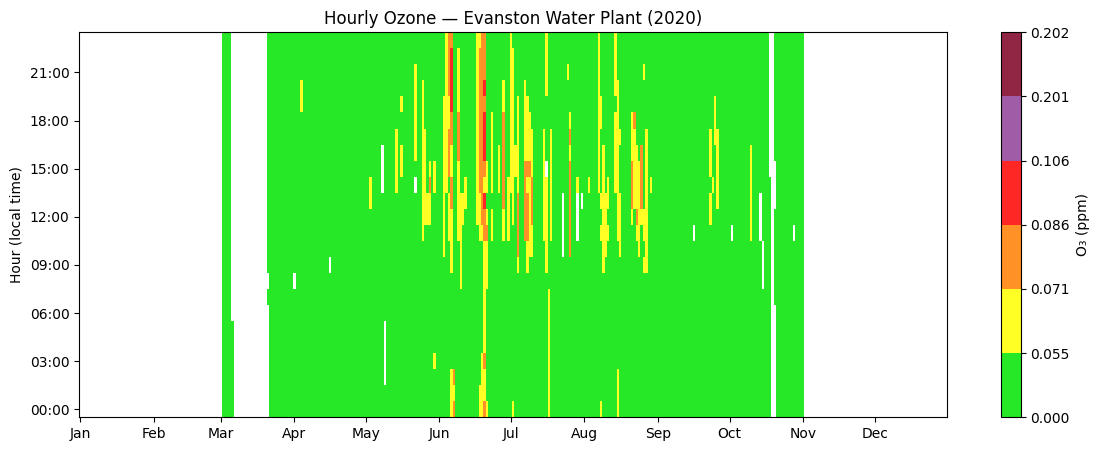

In [12]:
# Calandar/time-of-day heat map 

plot_time_heatmap(
    data=o3_hourly,
    datetime_col="datetime_local",
    value_col="sample_measurement",
    title=f"Hourly Ozone — {SITE_NAME} ({YEAR})",
    colorbar_label=f"{o3.symbol} ({o3.units})",
    aqi_pollutant="o3_8hr",
)
plt.show()


The heatmap reveals two characteristic patterns in ozone concentration. The 
**seasonal pattern** is visible horizontally — concentrations are highest in 
summer (June–August) when long days, intense sunlight, and warm temperatures 
drive photochemical ozone production. The **diurnal pattern** is visible 
vertically — ozone builds through the morning, peaks in the early-to-mid 
afternoon, and drops overnight as production stops and chemical loss continues. 
Elevated ozone can persist overnight and into the 
early morning hours, appearing as yellow or orange cells outside of peak 
afternoon hours. This overnight persistence reflects ozone retained under 
stable atmospheric conditions or mixed down from the residual layer above 
the nocturnal boundary layer rather than local photochemical production.

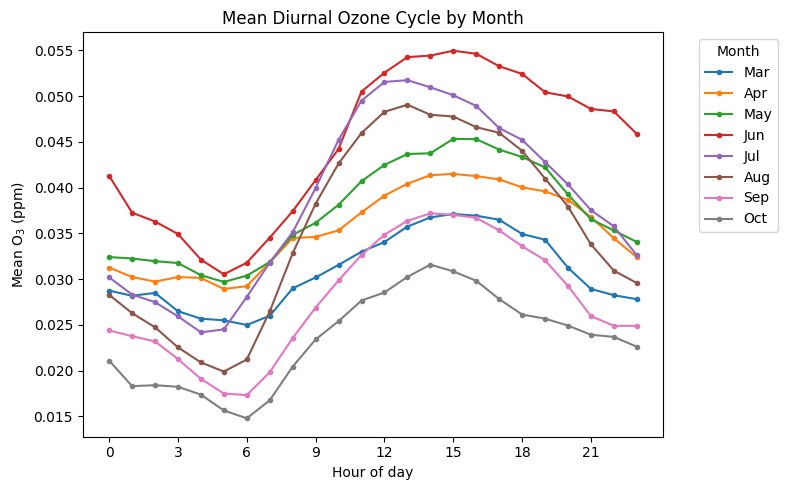

In [13]:
import calendar
o3_hourly["month"] = o3_hourly["datetime_local"].dt.month
o3_hourly["hour"] = o3_hourly["datetime_local"].dt.hour

monthly_diurnal = (
    o3_hourly
    .groupby(["month", "hour"])["sample_measurement"]
    .mean()
    .unstack("month")
)

plt.figure(figsize=(8, 5))

for month in monthly_diurnal.columns:
    plt.plot(
        monthly_diurnal.index,
        monthly_diurnal[month],
        marker="o",
        markersize=3,
        label=calendar.month_abbr[month]
    )

plt.xlabel("Hour of day")
plt.ylabel("Mean O$_3$ (ppm)")
plt.title("Mean Diurnal Ozone Cycle by Month")
plt.xticks(range(0, 24, 3))
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Each line shows the average ozone concentration by hour of day for one month.
The summer months (June–August) show both higher peak concentrations and higher 
overnight minima, consistent with the seasonal pattern visible in the calendar 
heatmap. Spring and fall months show lower and flatter diurnal curves, reflecting 
reduced photochemical activity compared to summer.

### Cumulative Distribution of Hourly Ozone

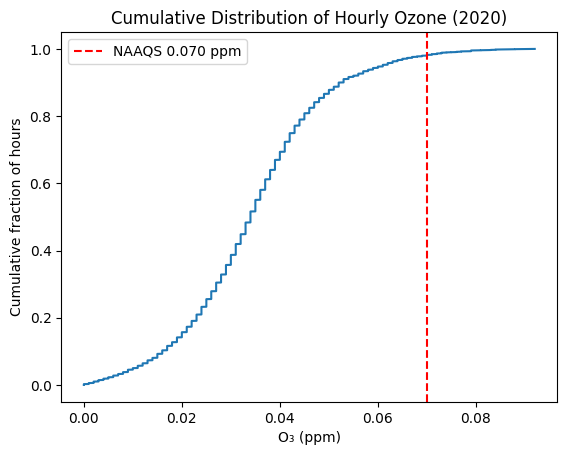

In [14]:
NAAQS_O3 = 0.070
sorted_o3 = np.sort(o3_hourly["sample_measurement"].dropna())
cdf = np.arange(1, len(sorted_o3) + 1) / len(sorted_o3)
plt.plot(sorted_o3, cdf)
plt.axvline(x=NAAQS_O3, color="red", linestyle="--", label="NAAQS 0.070 ppm")
plt.xlabel(f"{o3.symbol} ({o3.units})")
plt.ylabel("Cumulative fraction of hours")
plt.title(f"Cumulative Distribution of Hourly Ozone ({YEAR})")
plt.legend()
plt.show()

The cumulative distribution function (CDF) shows the fraction of hours during the 
year when ozone concentration was at or below a given level. Reading the curve from 
left to right, you can determine what percentage of hours fell below any threshold 
of interest. The dashed red line marks the NAAQS 8-hour standard of 0.070 ppm — 
the fraction of hours above this line represents times when ozone was in the 
Unhealthy for Sensitive Groups category or worse. The steep rise at low 
concentrations reflects the many nighttime and winter hours when ozone is near zero, 
while the long flat tail at high concentrations shows that the highest ozone levels 
are relatively rare events concentrated in summer afternoons.

## Daily Summaries

`aqs.bysite.dailysummary()` returns a DataFrame of daily summary statistics 
computed from the individual hourly measurements. Each row represents one day 
and one averaging period (e.g. 1-hour or 8-hour). Key columns include 
`first_max_value` (the highest average value that day), `first_max_hour` 
(the hour when that maximum began), `arithmetic_mean` (the daily average), 
and `pollutant_standard` (the NAAQS standard the summary was computed against). 
For ozone, both 1-hour and 8-hour summaries are returned and can be separated 
by filtering on `pollutant_standard`.

In [ ]:
o3_daily = aqs.bysite.dailysummary(
                        parameter=o3.code,                        
                        bdate=START_DT,
                        edate=END_DT,
                        stateFIPS=STATE_FIPS,
                        countycode=COUNTY_FIPS,
                        sitenum=SITE_NUM)

In [16]:
# Print o3_daily in a scrollable table
from IPython.display import display, HTML   
pd.set_option("display.max_rows", None)
display(HTML("<div style='height: 200px'>" + o3_daily.style.to_html() + "</div>"))

,state_code,county_code,site_number,parameter_code,poc,latitude,longitude,datum,parameter,sample_duration_code,sample_duration,pollutant_standard,date_local,units_of_measure,event_type,observation_count,observation_percent,validity_indicator,arithmetic_mean,first_max_value,first_max_hour,aqi,method_code,method,local_site_name,site_address,state,county,city,cbsa_code,cbsa,date_of_last_change
0,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-01,Parts per million,No Events,24,100.000000,Y,0.029417,0.046000,14,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26
1,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-02,Parts per million,No Events,24,100.000000,Y,0.027458,0.038000,14,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26
2,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-03,Parts per million,No Events,24,100.000000,Y,0.021458,0.036000,16,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26
3,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-04,Parts per million,No Events,24,100.000000,Y,0.027333,0.041000,14,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26
4,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-05,Parts per million,No Events,6,25.000000,N,0.017667,0.032000,1,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26
5,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-20,Parts per million,No Events,16,67.000000,Y,0.034313,0.041000,22,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26
6,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-21,Parts per million,No Events,24,100.000000,Y,0.041667,0.043000,1,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26
7,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-22,Parts per million,No Events,24,100.000000,Y,0.035750,0.038000,0,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26
8,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-23,Parts per million,No Events,24,100.000000,Y,0.031292,0.042000,17,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26
9,17,031,7002,44201,1,42.062053,-87.675254,WGS84,Ozone,1,1 HOUR,Ozone 1-hour 1979,2020-03-24,Parts per million,No Events,24,100.000000,Y,0.030208,0.047000,16,nan,087,INSTRUMENTAL - ULTRA VIOLET ABSORPTION,WATER PLANT,531 E. LINCOLN,Illinois,Cook,Evanston,16980,"Chicago-Naperville-Elgin, IL-IN-WI",2024-05-26


### Subsetting by Averaging Period

In [17]:
o3_daily_1hr = o3_daily.loc[
    o3_daily["pollutant_standard"] == "Ozone 1-hour 1979"
].copy()

o3_daily_8hr = o3_daily.loc[
    o3_daily["pollutant_standard"] == "Ozone 8-hour 2015"
].copy()

for df in [o3_daily_1hr, o3_daily_8hr]:
    df["date_local"] = pd.to_datetime(df["date_local"])
    df["first_max_datetime_local"] = (
        df["date_local"] + pd.to_timedelta(df["first_max_hour"], unit="h")
    )

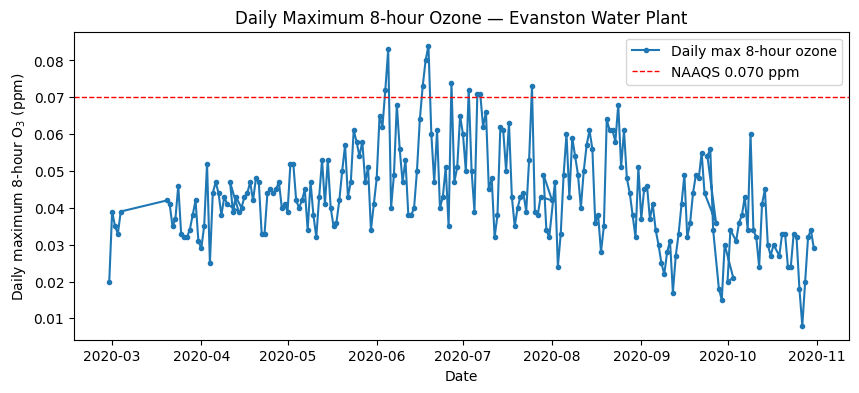

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(
    o3_daily_8hr["date_local"],
    o3_daily_8hr["first_max_value"],
    marker="o",
    linestyle="-",
    markersize=3,
    label="Daily max 8-hour ozone"
)

plt.axhline(
    0.070,
    color="red",
    linestyle="--",
    linewidth=1,
    label="NAAQS 0.070 ppm"
)

plt.xlabel("Date")
plt.ylabel("Daily maximum 8-hour O$_3$ (ppm)")
plt.title("Daily Maximum 8-hour Ozone — Evanston Water Plant")
plt.legend()
plt.show()

In [19]:
# AQS reports first_max_hour as the start of the 8-hour averaging window.
# For comparison with the 1-hour peak time, we plot the midpoint of the
# 8-hour window by adding 4 hours and wrapping onto a 0–23 hour clock.

o3_daily_8hr["first_max_midpoint_local"] = (
    o3_daily_8hr["first_max_datetime_local"] + pd.Timedelta(hours=4)
)
o3_daily_8hr["first_max_midpoint_hour"] = (
    o3_daily_8hr["first_max_midpoint_local"].dt.hour
)

### Distribution of Peak Ozone Hour

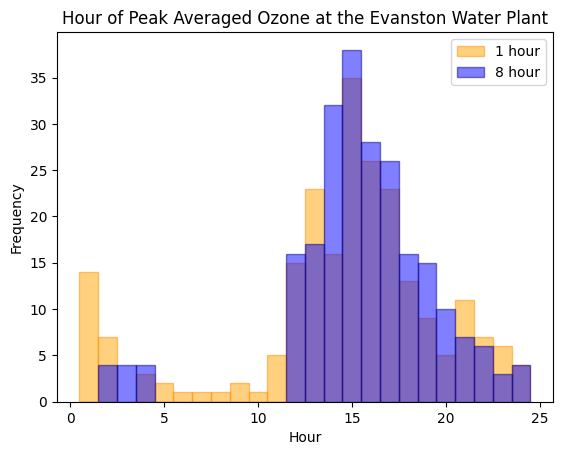

In [20]:
bins = np.linspace(start=0,stop=24,num=25)  # return evenly spaced numbers over an interval

plt.hist(o3_daily_1hr["first_max_hour"],bins, alpha=0.5, label="1 hour",color='orange',edgecolor='darkorange',align='right')
# The first_max_hour is when the average starts
plt.hist(o3_daily_8hr["first_max_midpoint_hour"],bins, alpha=0.5, label="8 hour",color='blue',edgecolor='darkblue',align='right')
plt.legend(loc='upper right')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.title('Hour of Peak Averaged Ozone at the Evanston Water Plant')
plt.show()

After shifting the 8-hour maximum from the start of its averaging window to the midpoint, the 1-hour and 8-hour peak-time distributions largely overlap. This is physically reasonable: the highest 8-hour window is usually centered near the afternoon ozone maximum.

### Top Peak Ozone Days

Many `first_max_hour` values occurring just after midnight are small — these likely 
represent falling ozone levels carried over from the previous day rather than a true 
morning peak. That observation is also supported by the heatmap. The tables below show the top `Ndays` days by peak ozone concentration. This is useful for identifying dates for further investigation.

In [21]:
Ndays = 5
o3_daily_8hr[['first_max_value','first_max_hour','date_local']].sort_values(by=['first_max_value'], ascending=False).head(Ndays)

,first_max_value,first_max_hour,date_local
788,0.084,15,2020-06-19
774,0.083,17,2020-06-05
787,0.080,12,2020-06-18
796,0.074,12,2020-06-27
786,0.073,14,2020-06-17


The max_hour above marks the start of the 8 hour window, so add 4 to compare to the data below.
Top days with max 1-hour ozone:

In [22]:
Ndays = 5
o3_daily_1hr[['first_max_value','first_max_hour','date_local']].sort_values(by=['first_max_value'], ascending=False).head(Ndays)

,first_max_value,first_max_hour,date_local
82,0.092,22,2020-06-05
96,0.090,16,2020-06-19
113,0.085,12,2020-07-06
162,0.084,14,2020-08-24
95,0.084,14,2020-06-18


### Monthly Distribution of Peak 8-hour Ozone

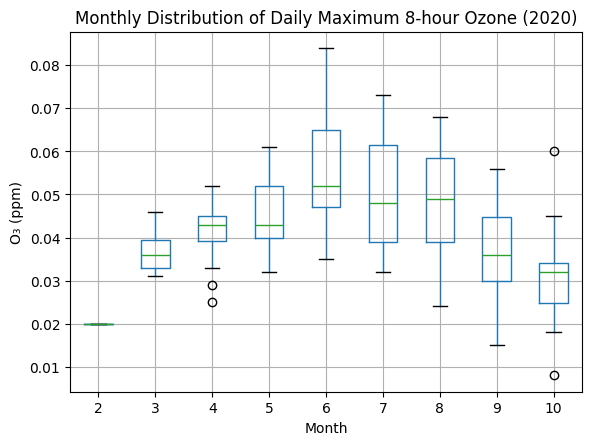

In [23]:
o3_daily_8hr["month"] = o3_daily_8hr["date_local"].dt.month
o3_daily_8hr.boxplot(column="first_max_value", by="month")
plt.xlabel("Month")
plt.ylabel(f"{o3.symbol} ({o3.units})")
plt.title(f"Monthly Distribution of Daily Maximum 8-hour Ozone ({YEAR})")
plt.suptitle("")
plt.show()

Each box summarizes the daily maximum 8-hour ozone values for one month. 
The horizontal line inside the box is the median, the box spans the 
interquartile range (25th to 75th percentile), and the whiskers extend 
to the most extreme values within 1.5 times the interquartile range. 
Points beyond the whiskers are outliers. The pronounced summer peak — 
with higher medians and wider boxes in June, July, and August — reflects 
the photochemical nature of ozone formation, which requires sunlight and 
warm temperatures. The narrow winter boxes show both lower ozone levels 
and less day-to-day variability during the cold months.